In [1]:
import matplotlib
matplotlib.use("Agg")
import plotly.io as pio
pio.renderers.default = "png"

# Bootstrapping & confidence intervals

Resample your data with replacement to build a **bootstrap distribution**, then
read a confidence interval off it.

## A bootstrap distribution for a mean

In [2]:
import moderndive as md
from moderndive import specify, get_confidence_interval, visualize, shade_confidence_interval

almonds = md.load_almonds_sample_100()

boot = (
    almonds.specify(response="weight")
    .generate(reps=1000, type="bootstrap", seed=1)
    .calculate(stat="mean")
)

## Confidence intervals — three methods

In [3]:
# Percentile method (default)
get_confidence_interval(boot, level=0.95, type="percentile")
# shape: (1, 2) → lower_ci ≈ 3.61, upper_ci ≈ 3.75

# Standard-error method (needs the point estimate)
point = float(almonds.specify(response="weight").calculate(stat="mean"))
get_confidence_interval(boot, level=0.95, type="se", point_estimate=point)

# Bias-corrected
get_confidence_interval(boot, level=0.95, type="bias-corrected", point_estimate=point)

lower_ci,upper_ci
f64,f64
3.613883,3.755272


Distribution objects also expose the getter as a method:

In [4]:
boot.get_confidence_interval(level=0.95, type="percentile")

lower_ci,upper_ci
f64,f64
3.606975,3.75


## Visualize the interval

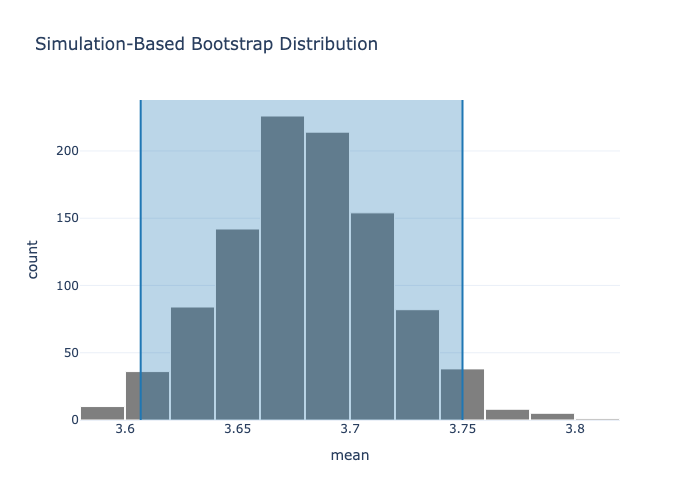

In [5]:
ci = get_confidence_interval(boot, level=0.95, type="percentile")

# plotly (default) — interactive
visualize(boot) + shade_confidence_interval(ci)

# plotnine
visualize(boot, engine="plotnine") + shade_confidence_interval(ci)

# one-call keyword form
visualize(boot, shade_ci=ci)

## A confidence interval for a proportion

In [6]:
import polars as pl

mythbusters = md.load_mythbusters_yawn()

boot_prop = (
    mythbusters.specify(response="yawn", success="yes")
    .generate(reps=1000, type="bootstrap", seed=1)
    .calculate(stat="prop")
)
get_confidence_interval(boot_prop, level=0.95, type="percentile")

lower_ci,upper_ci
f64,f64
0.1595,0.4


## A confidence interval for a difference

Add an explanatory variable and an `order=` to compare two groups:

In [7]:
boot_diff = (
    mythbusters.specify(formula="yawn ~ group", success="yes")
    .generate(reps=1000, type="bootstrap", seed=1)
    .calculate(stat="diff in props", order=("seed", "control"))
)
boot_diff.get_confidence_interval(level=0.95)

lower_ci,upper_ci
f64,f64
-0.224934,0.316189


```{seealso}
For *theory-based* intervals (the formula-based `t` interval) see
{doc}`theory-based`.
```